In [22]:
import sys
from pathlib import Path
import pandas as pd
import importlib.util

# ------------------------------------------------------------
# 1) Ensure project root is on sys.path (so "import src..." works)
#    Notebook is: ML/notebooks -> project root is one level up: ML/
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("find_spec('src'):", importlib.util.find_spec("src"))

# ------------------------------------------------------------
# 2) Import project config + feature engineering
# ------------------------------------------------------------
from src.config import PROCESSED_DIR, TRAIN_RACES, TEST_RACES
from src.features import add_features

print("PROCESSED_DIR:", PROCESSED_DIR)

# ------------------------------------------------------------
# 3) Load dataset ONCE (use the config path)
# ------------------------------------------------------------
csv_path = PROCESSED_DIR / "full_laptime_full.csv"   # <-- your filename
df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)

# ------------------------------------------------------------
# 4) Build engineered dataset (df_fe) for simulation use
# ------------------------------------------------------------
df_fe = add_features(df)
print("df_fe shape:", df_fe.shape)
print("Has TyreWearFrac?", "TyreWearFrac" in df_fe.columns)
print("Has lap_avg_3?", "lap_avg_3" in df_fe.columns)

numeric_pace = [
    "LapNumberNorm", "LapsSinceLastPit", "TyreLife", "Stint", "StopsSoFar", "Position", "lap_avg_3", "TyreWearFrac"
]
categorical_pace = ["Compound", "Team", "TrackStatus"]

features_pace = numeric_pace + categorical_pace

from src.features import add_features

df = pd.read_csv("../data/processed/full_laptime_full.csv")
df_fe = add_features(df)

# sanity
assert "LapTime_s" in df_fe.columns, "LapTime_s missing from df_fe"
assert "lap_avg_3" in df_fe.columns, "lap_avg_3 missing from df_fe"

# create LapDelta on df_fe (NOT train_df)
df_fe["LapDelta"] = (df_fe["LapTime_s"] - df_fe["lap_avg_3"]).fillna(0.0)

print("df_fe has LapDelta?", "LapDelta" in df_fe.columns)
print(df_fe[["LapTime_s","lap_avg_3","LapDelta"]].head(10))


PROJECT_ROOT: c:\Users\Josel\Dissertation\ML
find_spec('src'): ModuleSpec(name='src', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000016046674FD0>, origin='c:\\Users\\Josel\\Dissertation\\ML\\src\\__init__.py', submodule_search_locations=['c:\\Users\\Josel\\Dissertation\\ML\\src'])
PROCESSED_DIR: C:\Users\Josel\Dissertation\ML\data\processed
Loaded: C:\Users\Josel\Dissertation\ML\data\processed\full_laptime_full.csv
Shape: (95110, 16)
df_fe shape: (95110, 34)
Has TyreWearFrac? True
Has lap_avg_3? True
df_fe has LapDelta? True
   LapTime_s   lap_avg_3  LapDelta
0    101.738  101.738000  0.000000
1     93.227   97.482500 -4.255500
2     92.356   95.773667 -3.417667
3     93.137   92.906667  0.230333
4     92.652   92.715000 -0.063000
5     92.302   92.697000 -0.395000
6     91.987   92.313667 -0.326667
7     92.303   92.197333  0.105667
8     92.406   92.232000  0.174000
9     92.550   92.419667  0.130333


In [23]:
train_ids = {f"{year}-{race}" for (year, race) in TRAIN_RACES}
test_ids  = {f"{year}-{race}" for (year, race) in TEST_RACES}

train_df = df_fe[df_fe["RaceId"].isin(train_ids)].copy()
test_df  = df_fe[df_fe["RaceId"].isin(test_ids)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (90919, 35)
Test shape: (4191, 35)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor


# ---- sanity checks ----
print("train_df exists?", "train_df" in globals())
print("df_fe exists?", "df_fe" in globals())
print("features_pace exists?", "features_pace" in globals())
print("numeric_pace exists?", "numeric_pace" in globals())
print("categorical_pace exists?", "categorical_pace" in globals())

# 1) Check required columns exist
required = set(features_pace + ["LapNumber", "RaceId", "Driver", "LapTime_s"])
missing = [c for c in required if c not in train_df.columns]
print("Missing columns:", missing)

# 2) Ensure LapDelta exists (this is the #1 reason this cell fails)
if "LapDelta" not in train_df.columns:
    print("LapDelta not found -> creating LapDelta from LapTime_s and lap_avg_3")

    # build lap_avg_3 based on LapTime_s (NOT LapsSinceLastPit)
    g = train_df.sort_values(["RaceId","Driver","LapNumber"]).groupby(["RaceId","Driver"])
    train_df["lap_avg_3"] = (
        g["LapTime_s"].rolling(3, min_periods=1).mean().reset_index(level=[0,1], drop=True)
    )
    df_fe["LapDelta"] = (df_fe["LapTime_s"] - df_fe["lap_avg_3"]).fillna(0.0)


# if LapDelta still missing, hard stop
if "LapDelta" not in train_df.columns:
    raise ValueError("LapDelta still missing after creation. Something is wrong with LapTime_s / grouping.")

# 3) Define target + X/y
target_pace = "LapDelta"
X_train_pace = train_df[features_pace]
y_train_pace = train_df[target_pace]

X_test_pace = test_df[features_pace]
y_test_pace = test_df[target_pace]
#X_train_pace = train_df[features_pace].copy()
#y_train_pace = train_df[target_pace].astype(float).copy()

# 4) Basic cleaning: drop rows where target is NaN/inf
mask_ok = y_train_pace.replace([float("inf"), float("-inf")], float("nan")).notna()
#X_train_pace = X_train_pace.loc[mask_ok]
#y_train_pace = y_train_pace.loc[mask_ok]

print("X_train_pace shape:", X_train_pace.shape)
print("y_train_pace describe:\n", y_train_pace.describe())

# ---- preprocess ----
pre_pace = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_pace),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_pace),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

pace_model = Pipeline([
    ("preprocess", pre_pace),
    ("model", HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.08, max_iter=400, random_state=42
    ))
])

pace_model.fit(X_train_pace, y_train_pace)
print("pace_model trained ")



train_df exists? True
df_fe exists? True
features_pace exists? True
numeric_pace exists? True
categorical_pace exists? True
Missing columns: []
X_train_pace shape: (90919, 11)
y_train_pace describe:
 count    90919.000000
mean        -0.614253
std         19.814104
min      -1207.061000
25%         -0.298667
50%         -0.023333
75%          0.183667
max         43.120667
Name: LapDelta, dtype: float64
pace_model trained ✓


In [25]:
from pathlib import Path

out_dir = Path(r"C:\Users\Josel\Dissertation\ML\models")
out_dir.mkdir(parents=True, exist_ok=True)

(out_dir / "features_pace.txt").write_text("\n".join(features_pace))
print("Saved:", (out_dir / "features_pace.txt").resolve())
print("Num features:", len(features_pace))


Saved: C:\Users\Josel\Dissertation\ML\models\features_pace.txt
Num features: 11


In [26]:
from pathlib import Path
import joblib

# Save into Dissertation/ML/models/
out_dir = Path(r"C:\Users\Josel\Dissertation\ML\models")
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(pace_model, out_dir / "pace_model.joblib")
print("Saved:", (out_dir / "pace_model.joblib").resolve())


Saved: C:\Users\Josel\Dissertation\ML\models\pace_model.joblib


In [27]:
import numpy as np
import pandas as pd

from src.simulator import simulate_what_if_pit_stateful  # your existing function

# 1) Build the exact feature list the pace_model was trained on
features = features_pace

print("TyreLife in features?", "TyreLife" in features)
print("LapsSinceLastPit in features?", "LapsSinceLastPit" in features)
print("TyreWearFrac in features?", "TyreWearFrac" in features)
print("Compound in features?", "Compound" in features)
print("lap_avg_3 in features?", "lap_avg_3" in features)
print("pace_model in globals?", "pace_model" in globals())
print("df_fe in globals?", "df_fe" in globals())
print("features_pace in globals?", "features_pace" in globals())
print("numeric_pace in globals?", "numeric_pace" in globals())
print("categorical_pace in globals?", "categorical_pace" in globals())

sub = df_fe[(df_fe["RaceId"]=="2024-Abu Dhabi") & (df_fe["Driver"]=="LEC")].sort_values("LapNumber")
print(sub.loc[sub["LapNumber"].between(18, 21), ["LapNumber","LapTime_s","lap_avg_3"]])

# ------------------------------------------------------------
# 2) RUN THE WHAT-IF SIMULATION (this actually creates `result`)
# ------------------------------------------------------------
race_id = "2024-Abu Dhabi"
driver_code = "LEC"
pit_lap = 25

result = simulate_what_if_pit_stateful(
    df=df_fe,                 # engineered df
    pace_model=pace_model,
    race_id=race_id,
    driver_code=driver_code,
    pit_lap=pit_lap,
    pit_loss_s=22.0,
    horizon_laps=25,
    pace_features=features,   # NOTE: your function uses pace_features=
)

display(result.head(10))

# Quick sanity: is delta changing over time?
n_unique = result["Delta_WhatIf_minus_Base"].nunique()
std_delta = result["Delta_WhatIf_minus_Base"].std()
print(f"Delta unique values: {n_unique} | std(delta): {std_delta:.4f}")




TyreLife in features? True
LapsSinceLastPit in features? True
TyreWearFrac in features? True
Compound in features? True
lap_avg_3 in features? True
pace_model in globals? True
df_fe in globals? True
features_pace in globals? True
numeric_pace in globals? True
categorical_pace in globals? True
       LapNumber  LapTime_s  lap_avg_3
48784       18.0     89.841  89.743667
48785       19.0     90.082  89.831000
48786       20.0     92.189  90.704000
48787       21.0    108.662  96.977667


,LapNumber,PredLapTime_Base,PredLapTime_WhatIf,Delta_WhatIf_minus_Base,CumulativeDelta,RaceId,Driver,PitLap,PitLoss_s,HorizonLaps
0,25,88.912,141.407333,52.495333,52.495333,2024-Abu Dhabi,LEC,25,22.0,25
1,26,89.084,116.419626,27.335626,79.830959,2024-Abu Dhabi,LEC,25,22.0,25
2,27,88.873,108.564532,19.691532,99.522490,2024-Abu Dhabi,LEC,25,22.0,25
3,28,88.443,110.593396,22.150396,121.672886,2024-Abu Dhabi,LEC,25,22.0,25
4,29,88.560,109.654703,21.094703,142.767590,2024-Abu Dhabi,LEC,25,22.0,25
5,30,88.609,109.073346,20.464346,163.231936,2024-Abu Dhabi,LEC,25,22.0,25
6,31,88.485,111.392429,22.907429,186.139365,2024-Abu Dhabi,LEC,25,22.0,25
7,32,88.536,108.531100,19.995100,206.134465,2024-Abu Dhabi,LEC,25,22.0,25
8,33,88.518,108.748814,20.230814,226.365278,2024-Abu Dhabi,LEC,25,22.0,25
9,34,88.536,108.727663,20.191663,246.556941,2024-Abu Dhabi,LEC,25,22.0,25


Delta unique values: 25 | std(delta): 7.4367


In [28]:
# ------------------------------------------------------------
# 3) DIAGNOSTIC: does pace_model react to tyre ageing (coherently)?
# ------------------------------------------------------------
sub = df_fe[(df_fe["RaceId"] == race_id) & (df_fe["Driver"] == driver_code)].sort_values("LapNumber")
base_row = sub[sub["LapNumber"] == pit_lap].iloc[0].copy()

# helper: approximate wear cap (must match how you built TyreWearFrac)
WEAR_CAP = {"SOFT": 18, "MEDIUM": 25, "HARD": 35}
def wear_frac(tyre_life, compound):
    cap = WEAR_CAP.get(str(compound).upper(), 25)
    return float(np.clip(float(tyre_life) / cap, 0.0, 1.0))

tyre_lives = [1, 5, 10, 15, 20, 25]
rows = []
for tl in tyre_lives:
    r = base_row.copy()
    if "TyreLife" in r.index:
        r["TyreLife"] = tl
    if "LapsSinceLastPit" in r.index:
        r["LapsSinceLastPit"] = tl
    if "TyreWearFrac" in r.index:
        r["TyreWearFrac"] = wear_frac(tl, r.get("Compound", "MEDIUM"))
    # if you trained on lap_avg_3, keep it constant for this diagnostic (don’t confound)
    rows.append(r)

X = pd.DataFrame(rows)[features]
pred = pace_model.predict(X)

diag = pd.DataFrame({
    "TyreLife": tyre_lives,
    "TyreWearFrac": [wear_frac(tl, base_row.get("Compound","MEDIUM")) for tl in tyre_lives] if "TyreWearFrac" in features else np.nan,
    "Predicted": pred
})
display(diag)

# A quick numeric check: correlation should usually be positive if degradation slows the car
if len(pred) > 1:
    print("Corr(TyreLife, Predicted):", np.corrcoef(tyre_lives, pred)[0,1])


,TyreLife,TyreWearFrac,Predicted
0,1,0.028571,7.599333
1,5,0.142857,-0.612767
2,10,0.285714,-0.139296
3,15,0.428571,-0.139296
4,20,0.571429,-0.139296
5,25,0.714286,-0.139296


Corr(TyreLife, Predicted): -0.5950083580264407


In [29]:
# ------------------------------------------------------------
# 4) DEBUG: show baseline vs what-if feature values for first few laps
# ------------------------------------------------------------
sub = df_fe[(df_fe["RaceId"] == race_id) & (df_fe["Driver"] == driver_code)].sort_values("LapNumber").reset_index(drop=True)
window = sub[(sub["LapNumber"] >= pit_lap) & (sub["LapNumber"] < pit_lap + 6)].copy()

print("Real window (what baseline is templated from):")
display(window[["LapNumber","Compound","TyreLife","LapsSinceLastPit","TyreWearFrac"]].head())

print("Simulation deltas (first 6 laps):")
display(result[["LapNumber","PredLapTime_Base","PredLapTime_WhatIf","Delta_WhatIf_minus_Base"]].head(6))


Real window (what baseline is templated from):


,LapNumber,Compound,TyreLife,LapsSinceLastPit,TyreWearFrac
24,25.0,HARD,5.0,5,0.142857
25,26.0,HARD,6.0,6,0.171429
26,27.0,HARD,7.0,7,0.200000
27,28.0,HARD,8.0,8,0.228571
28,29.0,HARD,9.0,9,0.257143


Simulation deltas (first 6 laps):


,LapNumber,PredLapTime_Base,PredLapTime_WhatIf,Delta_WhatIf_minus_Base
0,25,88.912,141.407333,52.495333
1,26,89.084,116.419626,27.335626
2,27,88.873,108.564532,19.691532
3,28,88.443,110.593396,22.150396
4,29,88.560,109.654703,21.094703
5,30,88.609,109.073346,20.464346


In [30]:
sub = df_fe[(df_fe["RaceId"]=="2024-Abu Dhabi") & (df_fe["Driver"]=="LEC")].sort_values("LapNumber")
row = sub[sub["LapNumber"]==25].iloc[0].copy()

# vary TyreLife only
rows=[]
for tl in [1,5,10,15,20,25]:
    r=row.copy()
    r["TyreLife"]=tl
    rows.append(r)

X = pd.DataFrame(rows)[features]
pred = pace_model.predict(X)
pd.DataFrame({"TyreLife":[1,5,10,15,20,25], "PredLapDelta":pred})


,TyreLife,PredLapDelta
0,1,-0.612767
1,5,-0.612767
2,10,-0.612767
3,15,-0.612767
4,20,-0.612767
5,25,-0.612767


In [31]:
rows=[]
for w in [0.0,0.2,0.4,0.6,0.8,1.0]:
    r=row.copy()
    r["TyreWearFrac"]=w
    rows.append(r)

X = pd.DataFrame(rows)[features]
pred = pace_model.predict(X)
pd.DataFrame({"TyreWearFrac":[0,0.2,0.4,0.6,0.8,1.0], "PredLapDelta":pred})


,TyreWearFrac,PredLapDelta
0,0.0,-0.612767
1,0.2,-0.612767
2,0.4,-0.612767
3,0.6,-0.612767
4,0.8,-0.612767
5,1.0,-0.612767


Real pit laps: [20]


,LapNumber,LapTime_s,is_pit_lap,TrackStatus,TyreLife,Stint,lap_avg_3
48784,18.0,89.841,0,1,18.0,1.0,89.743667
48785,19.0,90.082,0,1,19.0,1.0,89.831000
48786,20.0,92.189,1,1,20.0,1.0,90.704000
48787,21.0,108.662,0,1,1.0,2.0,96.977667
48788,22.0,89.802,0,1,2.0,2.0,96.884333


rp/wp: 20 25
19 real 90.082 what 90.082 is_pit 0
20 real 92.189 what 89.831 is_pit 1
21 real 108.662 what 89.831 is_pit 0
22 real 89.802 what 89.802 is_pit 0
23 real 90.437 what 90.437 is_pit 0
24 real 89.185 what 89.185 is_pit 0
25 real 88.912 what 88.912 is_pit 0
len(sim_laps): 21
len(pred_laptime): 21
first/last sim_laps: [25 26 27] [43 44 45]
Monotonic cumtime? True
Pred laptime median/min/max: 88.518 88.09 110.274


,LapNumber,BasePos,WhatIfPos,DeltaCum_s,RefPace_used,PredDelta_used,PushBoostApplied_s,PredLapTime_used,TyreLife_used,LapsSinceLastPit_used,AheadDriver_loop,GapAhead_loop_s,PaceAdv_loop_s,TrafficPenalty_loop_s
0,25,6,3,-2.119000e+01,NaN,NaN,0.0,NaN,NaN,NaN,SAI,15.485,1.930,0.0
1,26,6,6,-4.547474e-13,NaN,NaN,0.0,NaN,NaN,NaN,HAM,10.462,-20.441,0.0
2,27,5,5,-4.547474e-13,NaN,NaN,0.0,NaN,NaN,NaN,HAM,9.491,0.971,0.0
3,28,5,5,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,8.453,1.038,0.0
4,29,5,5,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,7.257,1.196,0.0
5,30,4,4,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,6.380,0.877,0.0
6,31,4,4,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,5.151,1.229,0.0
7,32,4,4,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,3.885,1.266,0.0
8,33,4,4,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,HAM,2.814,1.071,0.0
9,34,3,3,0.000000e+00,NaN,NaN,0.0,NaN,NaN,NaN,SAI,20.178,-0.285,0.0


,LapNumber,TyreLife_used,LapsSinceLastPit_used,PredLapTime_used,DeltaCum_s
0,25,NaN,NaN,NaN,-2.119000e+01
1,26,NaN,NaN,NaN,-4.547474e-13
2,27,NaN,NaN,NaN,-4.547474e-13
3,28,NaN,NaN,NaN,0.000000e+00
4,29,NaN,NaN,NaN,0.000000e+00
5,30,NaN,NaN,NaN,0.000000e+00


...

,LapNumber,BasePos,WhatIfPos,DeltaCum_s,RefPace_used,PredDelta_used,PushBoostApplied_s,PredLapTime_used,TyreLife_used,LapsSinceLastPit_used,AheadDriver_loop,GapAhead_loop_s,PaceAdv_loop_s,TrafficPenalty_loop_s
0,25,6,3,-2.119000e+01,NaN,NaN,0.0,NaN,NaN,NaN,SAI,15.485,1.930,0.0
1,26,6,6,-4.547474e-13,NaN,NaN,0.0,NaN,NaN,NaN,HAM,10.462,-20.441,0.0
2,27,5,5,-4.547474e-13,NaN,NaN,0.0,NaN,NaN,NaN,HAM,9.491,0.971,0.0


   LapNumber  BasePos  WhatIfPos  BaseCumTime_s  WhatIfCumTime_s  \
0         25        6          3       2305.879         2284.689   
1         26        6          6       2394.963         2394.963   
2         27        5          5       2483.836         2483.836   
3         28        5          5       2572.279         2572.279   
4         29        5          5       2660.839         2660.839   
5         30        4          4       2749.448         2749.448   
6         31        4          4       2837.933         2837.933   
7         32        4          4       2926.469         2926.469   
8         33        4          4       3014.987         3014.987   
9         34        3          3       3103.523         3103.523   

     DeltaCum_s  TrafficPenalty_s AheadDriver  GapAhead_s BehindDriver  ...  \
0 -2.119000e+01               0.0         SAI      15.485          RUS  ...   
1 -4.547474e-13               0.0         HAM      10.462          GAS  ...   
2 -4.547474e-1

,LapNumber,WhatIfPos,AheadDriver,GapAhead_s,BehindDriver,GapBehind_s
0,25,3,SAI,15.485,RUS,1.212


,LapNumber,WhatIfPos,BasePos,DeltaCum_s,TrafficPenalty_s,AheadDriver_loop,GapAhead_loop_s,PaceAdv_loop_s
0,25,3,6,-2.119000e+01,0.0,SAI,15.485,1.930
1,26,6,6,-4.547474e-13,0.0,HAM,10.462,-20.441
2,27,5,5,-4.547474e-13,0.0,HAM,9.491,0.971
5,30,4,4,0.000000e+00,0.0,HAM,6.380,0.877
9,34,3,3,0.000000e+00,0.0,SAI,20.178,-0.285


,LapNumber,WhatIfPos,BasePos,DeltaCum_s,TrafficPenalty_s,AheadDriver_loop,GapAhead_loop_s,PaceAdv_loop_s,AheadDriver,GapAhead_s,BehindDriver,GapBehind_s
3,28,5,5,0.0,0.0,HAM,8.453,1.038,HAM,8.453,RUS,3.002
4,29,5,5,0.0,0.0,HAM,7.257,1.196,HAM,7.257,RUS,2.922
5,30,4,4,0.0,0.0,HAM,6.380,0.877,HAM,6.380,RUS,2.663
6,31,4,4,0.0,0.0,HAM,5.151,1.229,HAM,5.151,RUS,3.159
7,32,4,4,0.0,0.0,HAM,3.885,1.266,HAM,3.885,RUS,3.070


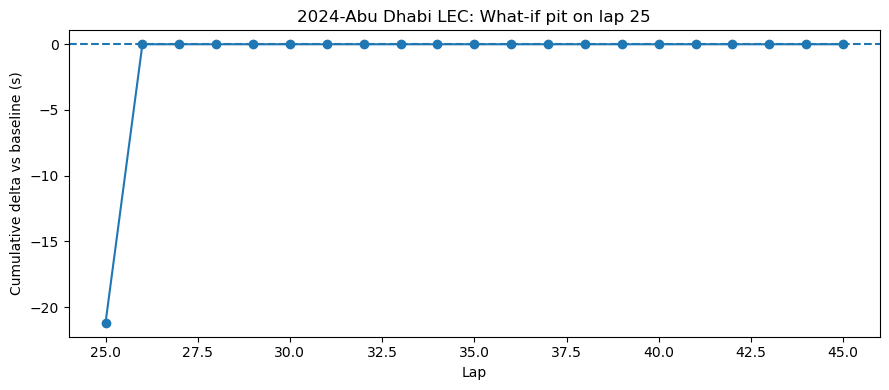

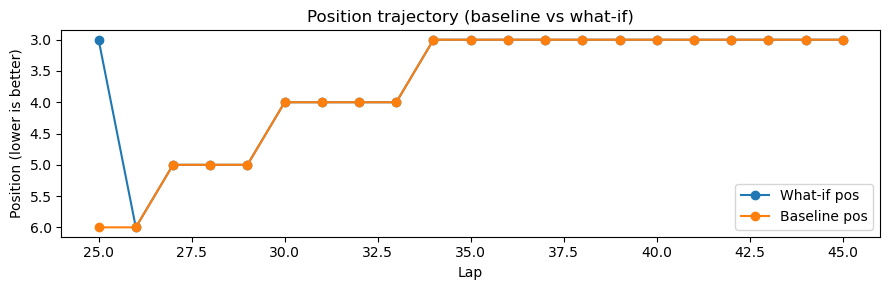

   LapNumber  BasePos  WhatIfPos  BaseCumTime_s  WhatIfCumTime_s  DeltaCum_s  \
0         25        6          3       2305.879         2284.689      -21.19   

   TrafficPenalty_s AheadDriver  GapAhead_s BehindDriver  ...  \
0               0.0         SAI      15.485          RUS  ...   

   GapAhead_loop_s  PaceAdv_loop_s TrafficPenalty_loop_s  PushBoostApplied_s  \
0           15.485            1.93                   0.0                 0.0   

   PredDelta_used  PredLapTime_used  TyreLife_used  LapsSinceLastPit_used  \
0             NaN               NaN            NaN                    NaN   

   RefPace_used  TyreAdj_used  
0           NaN           0.0  

[1 rows x 23 columns]


,LapNumber,BaseCumTime_s,WhatIfCumTime_s,DeltaCum_s
0,25,2305.879,2284.689,-2.119000e+01
1,26,2394.963,2394.963,-4.547474e-13
2,27,2483.836,2483.836,-4.547474e-13
3,28,2572.279,2572.279,0.000000e+00
4,29,2660.839,2660.839,0.000000e+00
5,30,2749.448,2749.448,0.000000e+00
6,31,2837.933,2837.933,0.000000e+00
7,32,2926.469,2926.469,0.000000e+00
8,33,3014.987,3014.987,0.000000e+00
9,34,3103.523,3103.523,0.000000e+00


WhatIfCumTime increments: [110.274  88.873  88.443  88.56   88.609  88.485  88.536  88.518  88.536]


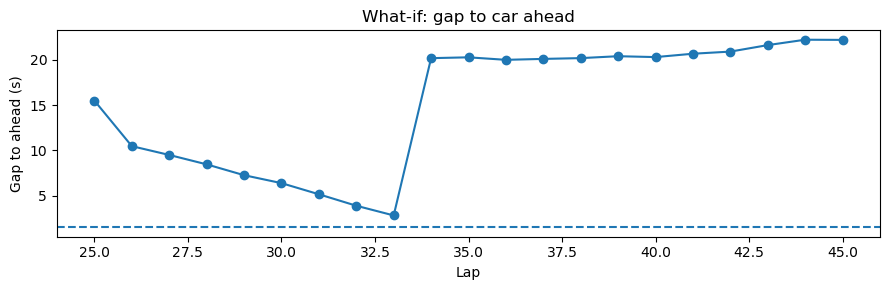

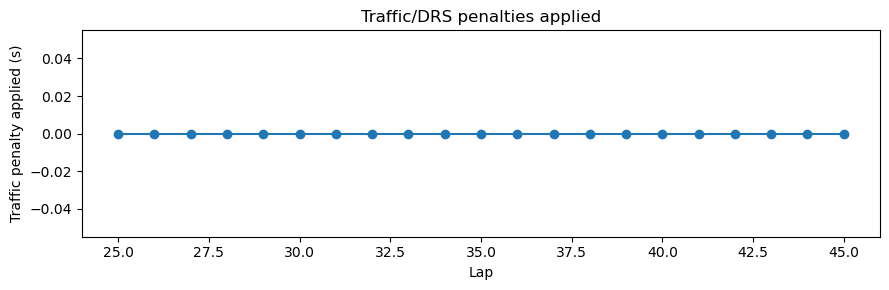

   LapNumber  BaseCumTime_s  WhatIfCumTime_s    DeltaCum_s
0         25       2305.879         2284.689 -2.119000e+01
1         26       2394.963         2394.963 -4.547474e-13
2         27       2483.836         2483.836 -4.547474e-13
3         28       2572.279         2572.279  0.000000e+00
4         29       2660.839         2660.839  0.000000e+00
5         30       2749.448         2749.448  0.000000e+00
6         31       2837.933         2837.933  0.000000e+00
7         32       2926.469         2926.469  0.000000e+00
WhatIf increments: [110.274  88.873  88.443  88.56   88.609  88.485  88.536]
pred median: -0.29643922817067303 min/max: -6.862728730003349 8.764890642517637


,LapNumber,WhatIfPos,AheadDriver,GapAhead_s,TrafficPenalty_s
0,25,3,SAI,15.485,0.0
1,26,6,HAM,10.462,0.0
2,27,5,HAM,9.491,0.0


   LapNumber  BasePos  WhatIfPos    DeltaCum_s  TrafficPenalty_s AheadDriver  \
0         25        6          3 -2.119000e+01               0.0         SAI   
1         26        6          6 -4.547474e-13               0.0         HAM   

   GapAhead_s  
0      15.485  
1      10.462  


,LapNumber,BasePos,WhatIfPos,BaseCumTime_s,WhatIfCumTime_s,DeltaCum_s,TrafficPenalty_s,AheadDriver,GapAhead_s,BehindDriver,...,GapAhead_loop_s,PaceAdv_loop_s,TrafficPenalty_loop_s,PushBoostApplied_s,PredDelta_used,PredLapTime_used,TyreLife_used,LapsSinceLastPit_used,RefPace_used,TyreAdj_used
0,25,6,3,2305.879,2284.689,-2.119000e+01,0.0,SAI,15.485,RUS,...,15.485,1.930,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0
1,26,6,6,2394.963,2394.963,-4.547474e-13,0.0,HAM,10.462,GAS,...,10.462,-20.441,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,27,5,5,2483.836,2483.836,-4.547474e-13,0.0,HAM,9.491,RUS,...,9.491,0.971,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0


WhatIfPos at pit lap: 3
Real pits: [20.0]
Real pit laps: [20]


,LapNumber,WhatIfCumTime_s,DeltaCum_s,TrafficPenalty_s,AheadDriver,GapAhead_s
0,25,2284.689,-2.119000e+01,0.0,SAI,15.485
1,26,2394.963,-4.547474e-13,0.0,HAM,10.462


,LapNumber,WhatIfPos,BasePos,AheadDriver_loop,GapAhead_loop_s,PaceAdv_loop_s,TrafficPenalty_loop_s,DeltaCum_s
0,25,3,6,SAI,15.485,1.930,0.0,-2.119000e+01
1,26,6,6,HAM,10.462,-20.441,0.0,-4.547474e-13
2,27,5,5,HAM,9.491,0.971,0.0,-4.547474e-13
5,30,4,4,HAM,6.380,0.877,0.0,0.000000e+00
6,31,4,4,HAM,5.151,1.229,0.0,0.000000e+00
7,32,4,4,HAM,3.885,1.266,0.0,0.000000e+00


rp/wp: 20 18
19 real 90.082 what 90.082 is_pit 0
len(sim_laps): 6
len(pred_laptime): 6
first/last sim_laps: [18 19 20] [21 22 23]
Monotonic cumtime? True
Pred laptime median/min/max: 89.83574999999999 89.802 111.27199999999999
rp/wp: 20 20
19 real 90.082 what 90.082 is_pit 0
20 real 92.189 what 92.189 is_pit 1
21 real 108.662 what 108.662 is_pit 0
len(sim_laps): 6
len(pred_laptime): 6
first/last sim_laps: [20 21 22] [23 24 25]
Monotonic cumtime? True
Pred laptime median/min/max: 90.1195 88.912 108.662
rp/wp: 20 25
19 real 90.082 what 90.082 is_pit 0
20 real 92.189 what 89.831 is_pit 1
21 real 108.662 what 89.831 is_pit 0
22 real 89.802 what 89.802 is_pit 0
23 real 90.437 what 90.437 is_pit 0
24 real 89.185 what 89.185 is_pit 0
25 real 88.912 what 88.912 is_pit 0
len(sim_laps): 6
len(pred_laptime): 6
first/last sim_laps: [25 26 27] [28 29 30]
Monotonic cumtime? True
Pred laptime median/min/max: 88.741 88.443 110.274
rp/wp: 29 30
28 real 90.274 what 90.274 is_pit 0
29 real 91.857 what 90

,RaceId,Driver,PitLap,RejoinPos,RejoinGapAhead,NetDeltaEnd,BasePosEnd,WhatIfPosEnd
4,2024-Abu Dhabi,HAM,33,3,17.079,0.00000,7,7
0,2024-Abu Dhabi,LEC,18,4,1.253,0.89680,7,7
1,2024-Abu Dhabi,LEC,20,4,3.406,1.09848,6,6
2,2024-Abu Dhabi,LEC,25,3,15.485,0.00000,4,4
3,2024-Abu Dhabi,VER,30,3,11.160,0.00000,9,9


In [32]:
import importlib
import src.simulator as simulator
importlib.reload(simulator)

from src.simulator import simulate_pit_rejoin_and_traffic


race_id = "2024-Abu Dhabi"
driver_code = "LEC"
pit_lap = 25

drv = df_fe[(df_fe["RaceId"]==race_id) & (df_fe["Driver"]==driver_code)].sort_values("LapNumber")
# --- Detect the real pit lap (first pit) ---
if "is_pit_lap" in drv.columns:
    pit_laps = drv.loc[drv["is_pit_lap"].astype(int)==1, "LapNumber"].astype(int).tolist()
else:
    pit_laps = []

real_pit_lap = pit_laps[0] if pit_laps else None

real_pits = drv.loc[drv["is_pit_lap"].astype(int)==1, "LapNumber"].astype(int).tolist()
print("Real pit laps:", real_pits)

if real_pits:
    rp = min(real_pits)
    display(drv.loc[(drv["LapNumber"]>=rp-2) & (drv["LapNumber"]<=rp+2),
                    ["LapNumber","LapTime_s","is_pit_lap","TrackStatus","TyreLife","Stint","lap_avg_3"]])

# IMPORTANT: pace_features must match what pace_model expects
pace_features = features_pace

result = simulate_pit_rejoin_and_traffic(
    df=df_fe,
    pace_model=pace_model,
    race_id=race_id,
    driver_code=driver_code,
    pit_lap=pit_lap,
    horizon_laps=20,
    pit_loss_s=22.0,
    pace_features=features_pace,
    traffic_gap_s=1.5,
    traffic_loss_s=0.6,
    pass_advantage_s=0.4,
    post_pit_push_laps=0,
    post_pit_push_boost_s=0.0,
)

cols = [
    "LapNumber","BasePos","WhatIfPos","DeltaCum_s",
    "RefPace_used","PredDelta_used","PushBoostApplied_s","PredLapTime_used",
    "TyreLife_used","LapsSinceLastPit_used",
    "AheadDriver_loop","GapAhead_loop_s","PaceAdv_loop_s","TrafficPenalty_loop_s"
]
display(result[result["LapNumber"].between(pit_lap-2, pit_lap+10)][cols])
display(
    result[result["LapNumber"].between(pit_lap, pit_lap+5)][
        ["LapNumber","TyreLife_used","LapsSinceLastPit_used","PredLapTime_used","DeltaCum_s"]
    ]
)


laps_to_check = [25, 26, 27]
check = df_fe[(df_fe["RaceId"]==race_id) & (df_fe["Driver"]==driver_code) & (df_fe["LapNumber"].isin(laps_to_check))][
    ["LapNumber"] + features_pace
].copy()

display(check)
display(
    result[result["LapNumber"].between(pit_lap, pit_lap+6)][
        ["LapNumber","TyreLife_used","LapsSinceLastPit_used","PredDelta_used","PredLapTime_used"]
    ]
)


display(result[result["LapNumber"].isin([pit_lap, pit_lap+1, pit_lap+2])][cols])
print(result.head(10))

print("Net delta by end:", float(result["DeltaCum_s"].iloc[-1]))
rejoin = result[result["LapNumber"] == pit_lap][
    ["LapNumber","WhatIfPos","AheadDriver","GapAhead_s","BehindDriver","GapBehind_s"]
]
display(rejoin)
import matplotlib.pyplot as plt

# Find lap(s) where position changed in what-if
pos_change = result["WhatIfPos"].diff()
display(result.loc[pos_change != 0, ["LapNumber","WhatIfPos","BasePos","DeltaCum_s","TrafficPenalty_s",
                                     "AheadDriver_loop","GapAhead_loop_s","PaceAdv_loop_s"]].head(20))

# Zoom around lap 28-32
display(result[(result["LapNumber"]>=28) & (result["LapNumber"]<=32)][
    ["LapNumber","WhatIfPos","BasePos","DeltaCum_s","TrafficPenalty_s",
     "AheadDriver_loop","GapAhead_loop_s","PaceAdv_loop_s",
     "AheadDriver","GapAhead_s","BehindDriver","GapBehind_s"]
])

result[result["LapNumber"].between(pit_lap, pit_lap+5)][
    ["LapNumber","TyreLife_used","LapsSinceLastPit_used","PredLapTime_used","DeltaCum_s"]
]

plt.figure(figsize=(9,4))
plt.plot(result["LapNumber"], result["DeltaCum_s"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Lap")
plt.ylabel("Cumulative delta vs baseline (s)")
plt.title(f"{race_id} {driver_code}: What-if pit on lap {pit_lap}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(result["LapNumber"], result["WhatIfPos"], marker="o", label="What-if pos")
plt.plot(result["LapNumber"], result["BasePos"], marker="o", label="Baseline pos")
plt.gca().invert_yaxis()
plt.xlabel("Lap")
plt.ylabel("Position (lower is better)")
plt.title("Position trajectory (baseline vs what-if)")
plt.legend()
plt.tight_layout()
plt.show()
print(result.loc[result["LapNumber"]==pit_lap, ["LapNumber","DeltaLap_s","TrafficPenalty_s"]] if "DeltaLap_s" in result.columns else result.loc[result["LapNumber"]==pit_lap].head(1))
tmp = result[["LapNumber","BaseCumTime_s","WhatIfCumTime_s","DeltaCum_s"]].head(10)
display(tmp)
print("WhatIfCumTime increments:", np.diff(tmp["WhatIfCumTime_s"].values))
plt.figure(figsize=(9,3))
plt.plot(result["LapNumber"], result["GapAhead_s"], marker="o")
plt.axhline(1.5, linestyle="--")
plt.xlabel("Lap"); plt.ylabel("Gap to ahead (s)")
plt.title("What-if: gap to car ahead")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,3))
plt.plot(result["LapNumber"], result["TrafficPenalty_s"], marker="o")
plt.xlabel("Lap"); plt.ylabel("Traffic penalty applied (s)")
plt.title("Traffic/DRS penalties applied")
plt.tight_layout(); plt.show()
print(result[["LapNumber","BaseCumTime_s","WhatIfCumTime_s","DeltaCum_s"]].head(8))
print("WhatIf increments:", np.diff(result["WhatIfCumTime_s"].values[:8]))
test_pred = pace_model.predict(df_fe[df_fe["RaceId"]==race_id].head(20)[features_pace])
print("pred median:", np.median(test_pred), "min/max:", np.min(test_pred), np.max(test_pred))
check = result[result["LapNumber"].isin([pit_lap, pit_lap+1, pit_lap+2])][
    ["LapNumber","WhatIfPos","AheadDriver","GapAhead_s","TrafficPenalty_s"]
]
display(check)
# result is output of simulate_pit_rejoin_and_traffic
print(result[result["LapNumber"].isin([19,20,21,24,25,26])][
    ["LapNumber","BasePos","WhatIfPos","DeltaCum_s","TrafficPenalty_s","AheadDriver","GapAhead_s"]
])

display(result.head(3))
print("WhatIfPos at pit lap:", result[result["LapNumber"]==pit_lap]["WhatIfPos"].iloc[0])
drv = df_fe[(df_fe["RaceId"]==race_id) & (df_fe["Driver"]==driver_code)].sort_values("LapNumber")
print("Real pits:", drv.loc[drv["is_pit_lap"].astype(int)==1, "LapNumber"].tolist())
real_pits = drv.loc[drv["is_pit_lap"].astype(int)==1, "LapNumber"].astype(int).tolist()
print("Real pit laps:", real_pits)

cols = ["LapNumber","WhatIfCumTime_s","DeltaCum_s","TrafficPenalty_s","AheadDriver","GapAhead_s"]
display(result[result["LapNumber"].isin([real_pits[0]-1, real_pits[0], real_pits[0]+1, pit_lap-1, pit_lap, pit_lap+1])][cols])
laps = [pit_lap, pit_lap+1, pit_lap+2, 30, 31, 32]
cols = ["LapNumber","WhatIfPos","BasePos","AheadDriver_loop","GapAhead_loop_s","PaceAdv_loop_s","TrafficPenalty_loop_s","DeltaCum_s"]
display(result[result["LapNumber"].isin(laps)][cols])

tests = [
    ("2024-Abu Dhabi", "LEC", 18),
    ("2024-Abu Dhabi", "LEC", 20),
    ("2024-Abu Dhabi", "LEC", 25),
    ("2024-Abu Dhabi", "VER", 30),
    ("2024-Abu Dhabi", "HAM", 33),
]

rows = []
for race_id, driver_code, pit_lap in tests:
    out = simulate_pit_rejoin_and_traffic(
        df=df_fe,
        pace_model=pace_model,
        race_id=race_id,
        driver_code=driver_code,
        pit_lap=pit_lap,
        horizon_laps=5,
        pit_loss_s=22.0,
        pace_features=features_pace,
        traffic_gap_s=1.5,
        traffic_loss_s=0.6,
        pass_advantage_s=0.4,
        post_pit_push_laps=3,
        post_pit_push_boost_s=0.8,
    )

    rejoin = out[out["LapNumber"] == pit_lap].iloc[0]
    rows.append({
        "RaceId": race_id,
        "Driver": driver_code,
        "PitLap": pit_lap,
        "RejoinPos": int(rejoin["WhatIfPos"]),
        "RejoinGapAhead": float(rejoin["GapAhead_s"]) if pd.notna(rejoin["GapAhead_s"]) else None,
        "NetDeltaEnd": float(out["DeltaCum_s"].iloc[-1]),
        "BasePosEnd": int(out["BasePos"].iloc[-1]),
        "WhatIfPosEnd": int(out["WhatIfPos"].iloc[-1]),
    })

pd.DataFrame(rows).sort_values(["RaceId","Driver","PitLap"])


In [33]:
tests = [
    ("2024-Abu Dhabi", "LEC", 18),
    ("2024-Abu Dhabi", "LEC", 20),
    ("2024-Abu Dhabi", "LEC", 25),
    ("2024-Abu Dhabi", "NOR", 18),
    ("2024-Abu Dhabi", "HAM", 18),
]

rows = []
for race_id, driver_code, pit_lap in tests:
    out = simulate_pit_rejoin_and_traffic(
        df=df_fe,
        pace_model=pace_model,
        race_id=race_id,
        driver_code=driver_code,
        pit_lap=pit_lap,
        horizon_laps=20,
        pit_loss_s=22.0,
        pace_features=features_pace,
        traffic_gap_s=1.5,
        traffic_loss_s=0.6,
        pass_advantage_s=0.4,
        post_pit_push_laps=3,
        post_pit_push_boost_s=0.8,
    )

    rejoin = out[out["LapNumber"] == pit_lap].iloc[0]
    rows.append({
        "RaceId": race_id,
        "Driver": driver_code,
        "PitLap": pit_lap,
        "RejoinPos": int(rejoin["WhatIfPos"]),
        "RejoinGapAhead": float(rejoin["GapAhead_s"]) if pd.notna(rejoin["GapAhead_s"]) else None,
        "NetDeltaEnd": float(out["DeltaCum_s"].iloc[-1]),
        "BasePosEnd": int(out["BasePos"].iloc[-1]),
        "WhatIfPosEnd": int(out["WhatIfPos"].iloc[-1]),
    })

pd.DataFrame(rows).sort_values(["RaceId","Driver","PitLap"])


rp/wp: 20 18
19 real 90.082 what 90.082 is_pit 0
len(sim_laps): 21
len(pred_laptime): 21
first/last sim_laps: [18 19 20] [36 37 38]
Monotonic cumtime? True
Pred laptime median/min/max: 88.609 88.09 111.27199999999999
rp/wp: 20 20
19 real 90.082 what 90.082 is_pit 0
20 real 92.189 what 92.189 is_pit 1
21 real 108.662 what 108.662 is_pit 0
len(sim_laps): 21
len(pred_laptime): 21
first/last sim_laps: [20 21 22] [38 39 40]
Monotonic cumtime? True
Pred laptime median/min/max: 88.56 88.09 108.662
rp/wp: 20 25
19 real 90.082 what 90.082 is_pit 0
20 real 92.189 what 89.831 is_pit 1
21 real 108.662 what 89.831 is_pit 0
22 real 89.802 what 89.802 is_pit 0
23 real 90.437 what 90.437 is_pit 0
24 real 89.185 what 89.185 is_pit 0
25 real 88.912 what 88.912 is_pit 0
len(sim_laps): 21
len(pred_laptime): 21
first/last sim_laps: [25 26 27] [43 44 45]
Monotonic cumtime? True
Pred laptime median/min/max: 88.518 88.09 110.274
rp/wp: 26 18
len(sim_laps): 21
len(pred_laptime): 21
first/last sim_laps: [18 19 

,RaceId,Driver,PitLap,RejoinPos,RejoinGapAhead,NetDeltaEnd,BasePosEnd,WhatIfPosEnd
4,2024-Abu Dhabi,HAM,18,6,5.183,2.961163e+00,7,7
0,2024-Abu Dhabi,LEC,18,4,1.253,8.968000e-01,3,3
1,2024-Abu Dhabi,LEC,20,4,3.406,1.098480e+00,3,3
2,2024-Abu Dhabi,LEC,25,3,15.485,-4.547474e-13,3,3
3,2024-Abu Dhabi,NOR,18,1,NaN,4.547474e-13,1,1
